## Import dependencies

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import os

## Applying categorization: Omega Plane and Average Methods

In [2]:
LOCAL_PATH = "/g/data/k10/zr7147/raw/orcestra_level4.nc"
OUT_PATH = "/g/data/k10/zr7147/processed/orcestra_level4_categorized.nc"
ds = xr.open_dataset(LOCAL_PATH).load()

In [ ]:
import numpy as np
import pandas as pd

res_angle = []
res_plane = []
res_avg_check = [] 

# Constants for the Li et al. (2025) Method
P_SFC = 1000.0  # Surface Pressure (hPa)
P_TOP = 100.0   # Tropopause Pressure (hPa)
P_MID = 550.0   # Mid-point for the average method

# --- Magnitude Threshold ---
# You will need to tune this value! Plot a histogram of your `r_mag` values 
# to find a good cutoff where the profiles turn into chaotic spaghetti.
R_THRESHOLD = 20.0 

for c in ds.circle.values:
    omega = ds['omega'].sel(circle=c).values
    p_hpa = ds['p_mean'].sel(circle=c).values / 100  # Convert Pa to hPa
    
    # 1. Filter: Missing Data
    if np.isnan(omega).all():
        res_angle.append(np.nan)
        res_plane.append("Missing Data")
        res_avg_check.append("Missing Data")
        continue

    # --- Adjusted Omega Angle Plane Method ---
    mask = ~np.isnan(omega) & ~np.isnan(p_hpa)
    o_v, p_v = -omega[mask], p_hpa[mask] # Note: -omega so ascent is positive
    
    p_star = (p_v - P_TOP) / (P_SFC - P_TOP)
    m1 = np.sin(np.pi * p_star)
    m2 = np.sin(2 * np.pi * p_star)
    
    c1 = np.trapezoid(o_v * m1, p_v)
    c2 = np.trapezoid(o_v * m2, p_v)
    
    # --- Calculate Magnitude (Radius) ---
    r_mag = np.sqrt(c1**2 + c2**2)
    
    angle = np.degrees(np.arctan2(c2, c1)) 
    res_angle.append(angle)
    
    # --- 3-Category Logic ---
    if r_mag < R_THRESHOLD:
        # Catches points too close to the origin (weak/ambiguous)
        res_plane.append("Suppressed / Weak")
        
    elif -60 <= angle <= 0:
        # Tightened boundary for robust deep bottom-heavy convection
        res_plane.append("Bottom-Heavy")
        
    elif 0 < angle <= 60:
        # Tightened boundary for robust deep top-heavy convection
        res_plane.append("Top-Heavy")
        
    else:
        # Catches > 60 (Stratiform), < -60 (Shallow), and Subsidence (>150, <-150)
        res_plane.append("Suppressed / Weak")

    # --- Method 2: Upper vs Lower Average (Unchanged) ---
    upper_mask = (p_hpa > P_TOP) & (p_hpa < P_MID)
    lower_mask = (p_hpa >= P_MID) & (p_hpa < P_SFC)
    
    avg_upper = np.nanmean(omega[upper_mask])
    avg_lower = np.nanmean(omega[lower_mask])
    
    if avg_upper < avg_lower:
        res_avg_check.append("Top-Heavy (Average Method)")
    else:
        res_avg_check.append("Bottom-Heavy (Average Method)")

# Save results into the dataset
ds['top_heaviness_angle'] = (('circle'), res_angle)
ds['category_plane'] = (('circle'), res_plane)
ds['category_avg'] = (('circle'), res_avg_check)

print("Comparison of Categorization Methods:")
print("-" * 30)
print("Adjusted Plane Method (3-Category + Magnitude Filter):")
print(pd.Series(res_plane).value_counts())
print("\nFixed Average Method (Upper vs Lower):")
print(pd.Series(res_avg_check).value_counts())

Comparison of Categorization Methods:
------------------------------
Adjusted Plane Method (3-Category + Magnitude Filter):
Suppressed / Weak    75
Top-Heavy             6
Bottom-Heavy          6
Missing Data          2
Name: count, dtype: int64

Fixed Average Method (Upper vs Lower):
Bottom-Heavy (Average Method)    52
Top-Heavy (Average Method)       35
Missing Data                      2
Name: count, dtype: int64


In [4]:
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
if os.path.exists(OUT_PATH):
    os.remove(OUT_PATH)

ds.to_netcdf(OUT_PATH)
print(f"Saved to: {OUT_PATH}")

Saved to: /g/data/k10/zr7147/processed/orcestra_level4_categorized.nc


## Convert to CSV

In [6]:
# Verify categorization logic and save results to CSV

CSV_PATH = "/g/data/k10/zr7147/processed/omega_plane_categorization.csv"

# Build verification DataFrame
df = pd.DataFrame({
    'circle':              ds.circle.values,
    'circle_time':         pd.to_datetime(ds['circle_time'].values),
    'angle_deg':           res_angle,
    'category_omega_plane': res_plane,
    'category_avg_method': res_avg_check,
})

# Verify each angle matches the correct category boundary
def expected_category(angle):
    if pd.isna(angle):
        return "Missing Data"
    if -27 <= angle <= 0:
        return "Bottom-Heavy (Fully Ascending)"
    elif -150 < angle < -27:
        return "Bottom-Heavy"
    elif 0 < angle <= 27:
        return "Top-Heavy (Fully Ascending)"
    elif 27 < angle < 150:
        return "Top-Heavy"
    else:
        return "Inactive / Suppressed"

df['expected_category'] = df['angle_deg'].apply(expected_category)
df['logic_correct'] = (
    (df['category_omega_plane'] == df['expected_category']) |
    (df['category_omega_plane'] == "Missing Data")
)

n_wrong = (~df['logic_correct']).sum()
print(f"Logic verification: {df['logic_correct'].sum()}/{len(df)} circles correct")
if n_wrong > 0:
    print(f"WARNING: {n_wrong} circles have incorrect categories:")
    print(df[~df['logic_correct']][['circle', 'angle_deg', 'category_omega_plane', 'expected_category']])
else:
    print("All category assignments match the angle boundaries.")

# Save to CSV
os.makedirs(os.path.dirname(CSV_PATH), exist_ok=True)
df.to_csv(CSV_PATH, index=False)
print(f"\nSaved to: {CSV_PATH}")

# Print summary table
print("\nCategory summary:")
print(df['category_omega_plane'].value_counts().to_string())
print("\nSample (first 15 rows):")
print(df[['circle', 'circle_time', 'angle_deg', 'category_omega_plane']].head(15).to_string(index=False))

Logic verification: 89/89 circles correct
All category assignments match the angle boundaries.

Saved to: /g/data/k10/zr7147/processed/omega_plane_categorization.csv

Category summary:
category_omega_plane
Top-Heavy                         27
Inactive / Suppressed             19
Bottom-Heavy                      17
Top-Heavy (Fully Ascending)       15
Bottom-Heavy (Fully Ascending)     9
Missing Data                       2

Sample (first 15 rows):
 circle             circle_time   angle_deg        category_omega_plane
      0 2024-08-11 14:45:42.500    5.585413 Top-Heavy (Fully Ascending)
      1 2024-08-11 16:43:52.000  134.866562                   Top-Heavy
      2 2024-08-11 17:49:57.000   10.696177 Top-Heavy (Fully Ascending)
      3 2024-08-11 19:35:32.000 -151.766891       Inactive / Suppressed
      4 2024-08-13 17:50:50.500 -168.985336       Inactive / Suppressed
      5 2024-08-13 19:43:38.000  116.309807                   Top-Heavy
      6 2024-08-13 21:36:15.500    4.806720

## Create plots

In [5]:
ds = xr.open_dataset(OUT_PATH).load()
ds

<xarray.Dataset> Size: 117MB
Dimensions:                   (circle: 89, altitude: 1460, sonde: 1058)
Coordinates:
    circle_lat                (circle) float32 356B 5.0 8.25 ... 12.17 10.76
    circle_lon                (circle) float32 356B -27.0 -26.39 ... -56.91
    circle_time               (circle) datetime64[ns] 712B 2024-08-11T14:45:4...
    sondes_per_circle         (circle) int64 712B 12 12 10 12 12 ... 14 14 12 13
  * altitude                  (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    launch_time               (sonde) datetime64[ns] 8kB 2024-08-11T14:17:01 ...
Dimensions without coordinates: circle, sonde
Data variables: (12/76)
    circle_altitude           (circle) float32 356B 1.387e+04 ... 1.441e+04
    circle_id                 (circle) |S200 18kB b'HALO-20240811a_50ca' ... ...
    circle_radius             (circle) float32 356B 1.331e+05 ... 1.331e+05
    div                       (circle, altitude) float32 520kB 1.087e-05 ... nan
    div_sonde_relevance       (sonde, altitude) float32 6MB -2.032e-06 ... nan
    div_std_error             (circle, altitude) float32 520kB 7.325e-06 ... nan
    ...                        ...
    wvel_std_error            (circle, altitude) float32 520kB nan ... nan
    x                         (sonde, altitude) float32 6MB -2.337e+04 ... 5....
    y                         (sonde, altitude) float32 6MB -1.327e+05 ... -4...
    top_heaviness_angle       (circle) float64 712B 5.585 134.9 ... 17.45 -1.024
    category_plane            (circle) <U17 6kB 'Suppressed / Weak' ... 'Supp...
    category_avg              (circle) <U29 10kB 'Bottom-Heavy (Average Metho...
Attributes:
    creator_email:  helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpimet...
    creator_name:   Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    featureType:    trajectoryProfile
    history:        Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 qual...
    keywords:       ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmospher...
    license:        CC-BY-4.0
    platform:       HALO
    project:        ORCESTRA, PERCUSION, MAESTRO
    references:     https://github.com/atmdrops/pydropsonde
    source:         dropsondes
    summary:        This dataset is the Level 4 BEACH dataset. It contains on...
    title:          BEACH dropsonde dataset (Level 4)


GENERATING AND SAVING PLOTS FOR: BOTTOM-HEAVY
Total Circles: 6

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Method_Spaghetti_Bottom-Heavy.png


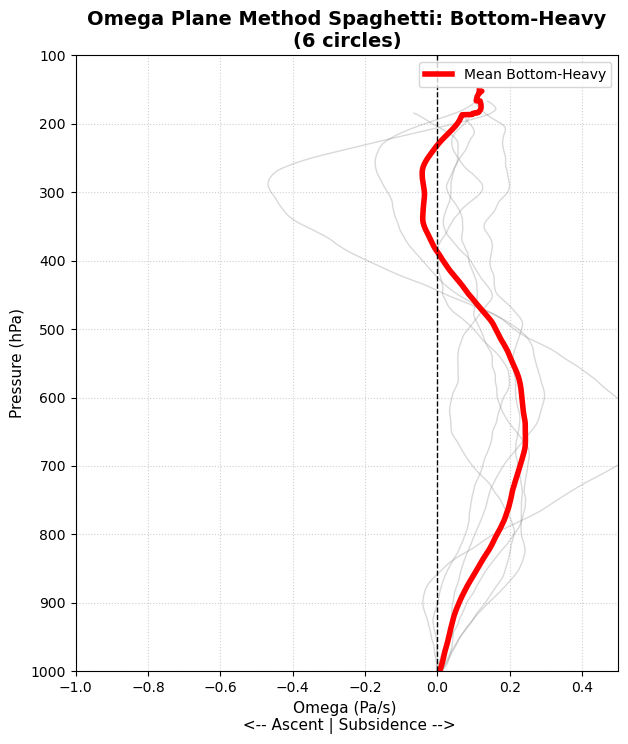

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Grid_Bottom-Heavy.png


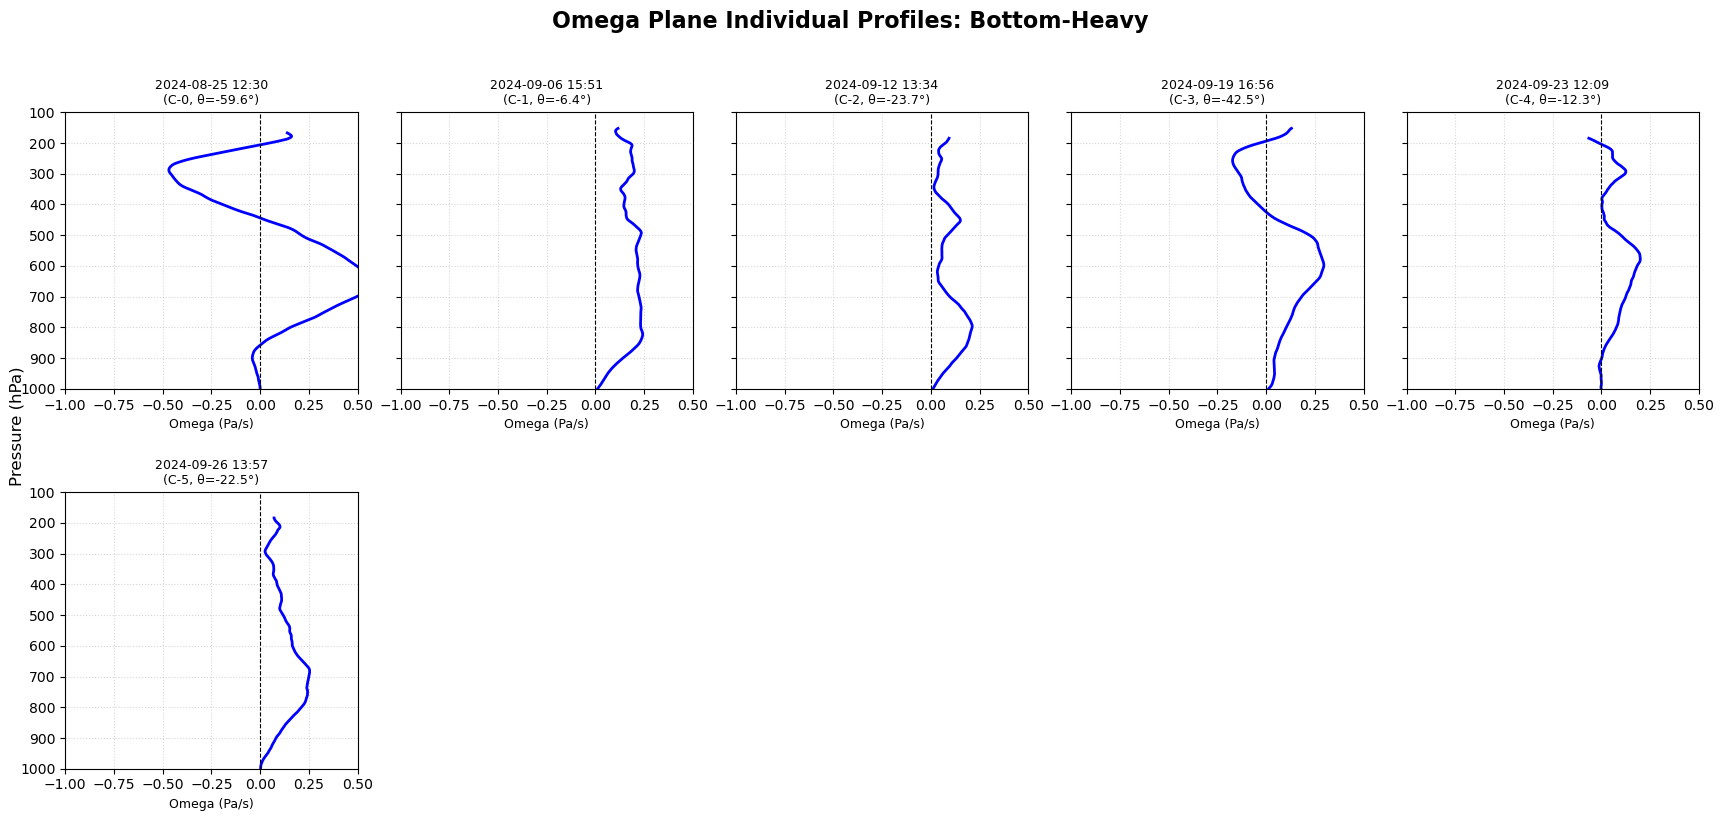


GENERATING AND SAVING PLOTS FOR: SUPPRESSED / WEAK
Total Circles: 75

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Method_Spaghetti_Suppressed_Weak.png


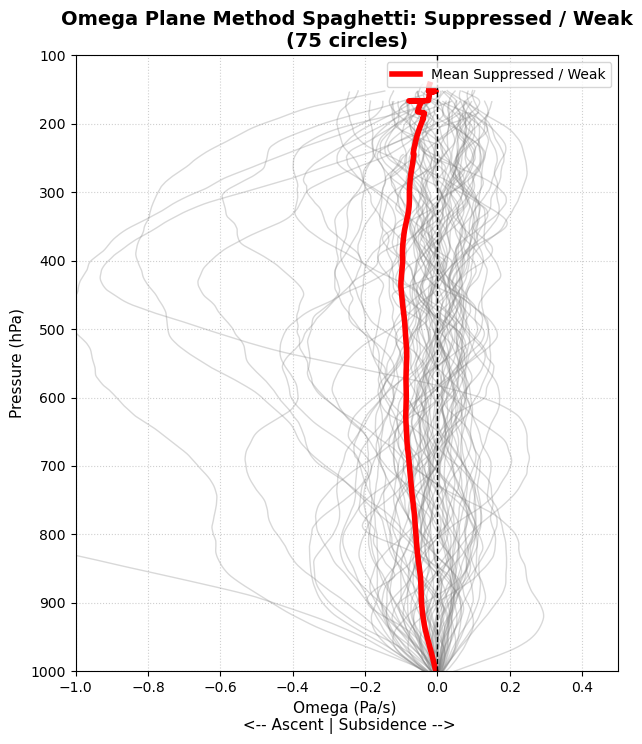

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Grid_Suppressed_Weak.png


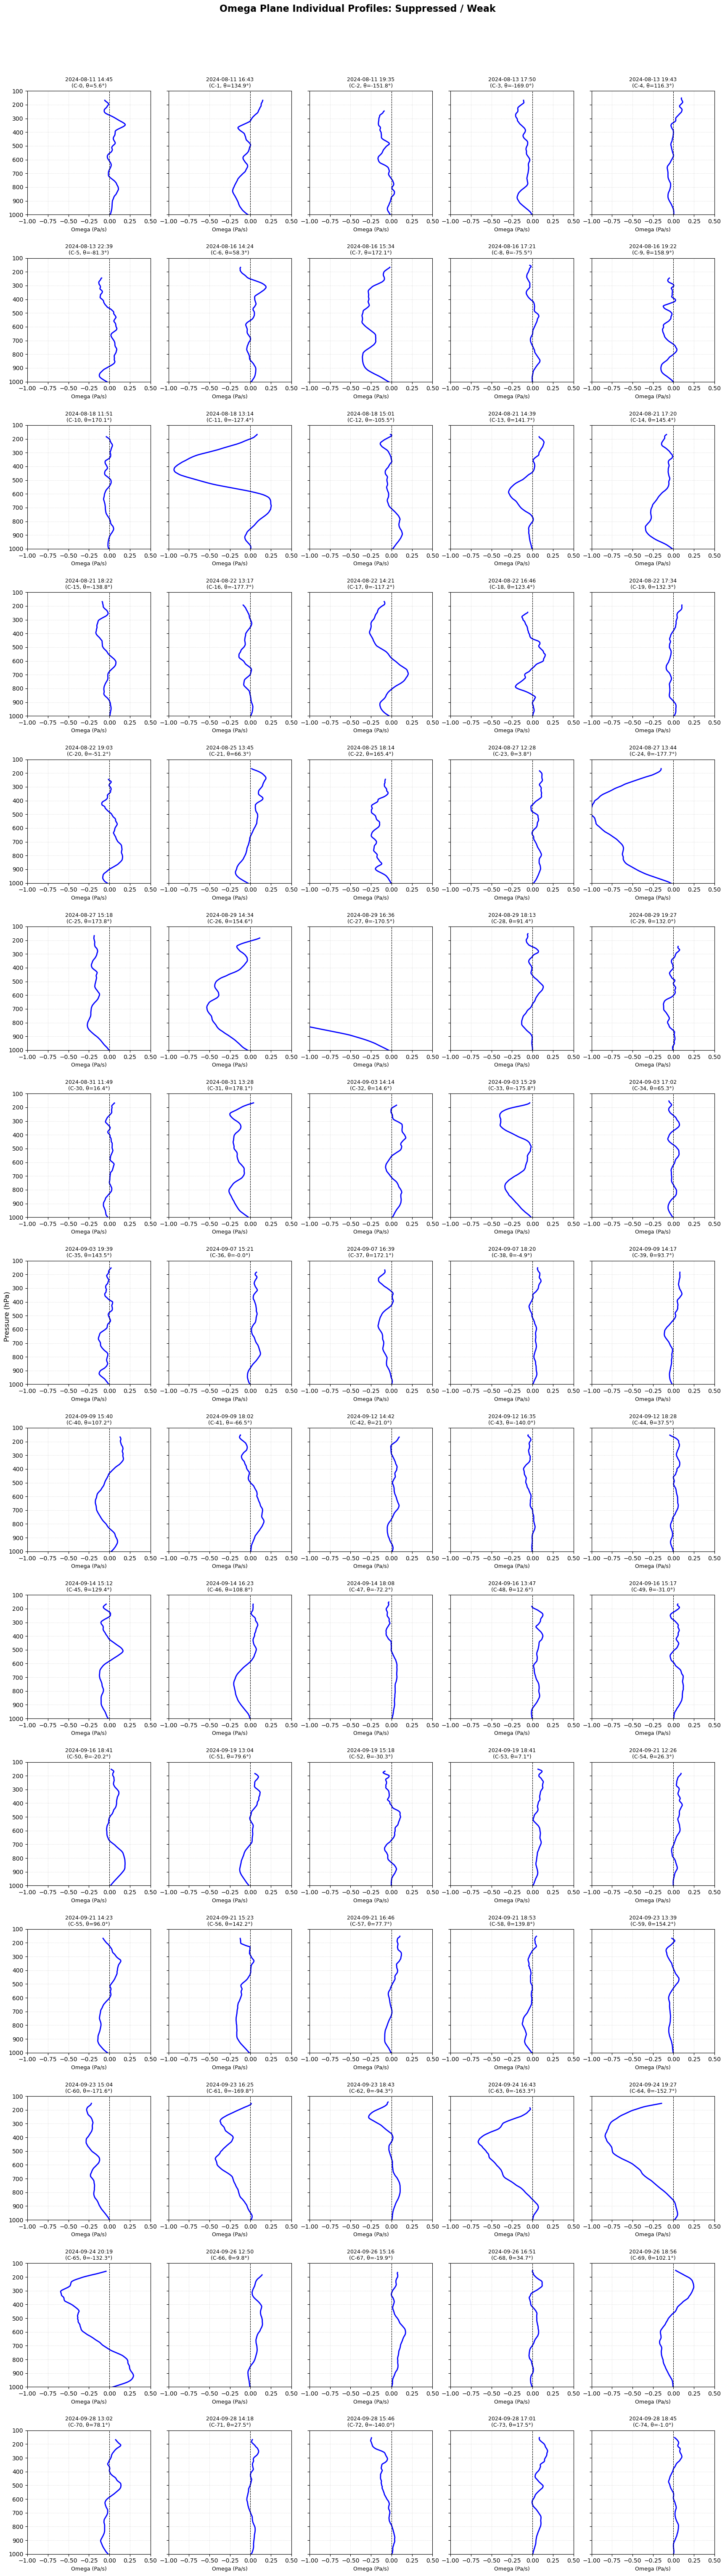


GENERATING AND SAVING PLOTS FOR: TOP-HEAVY
Total Circles: 6

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Method_Spaghetti_Top-Heavy.png


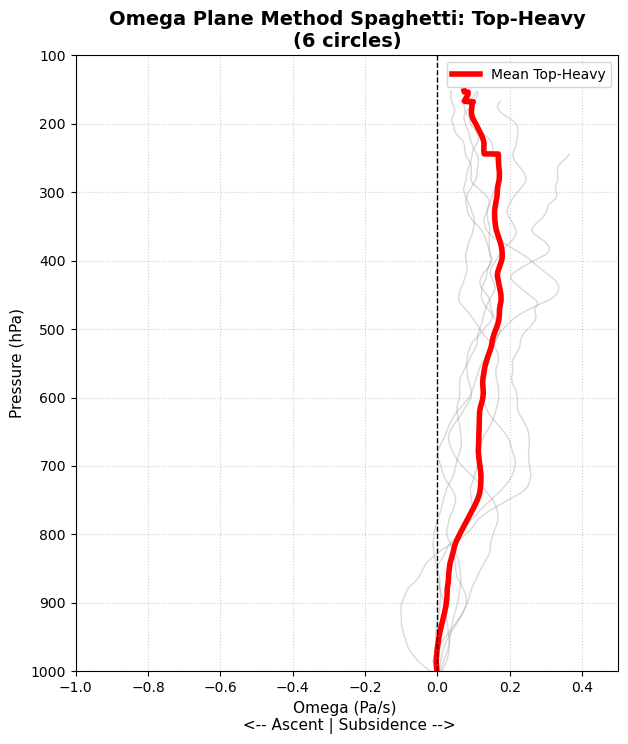

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Grid_Top-Heavy.png


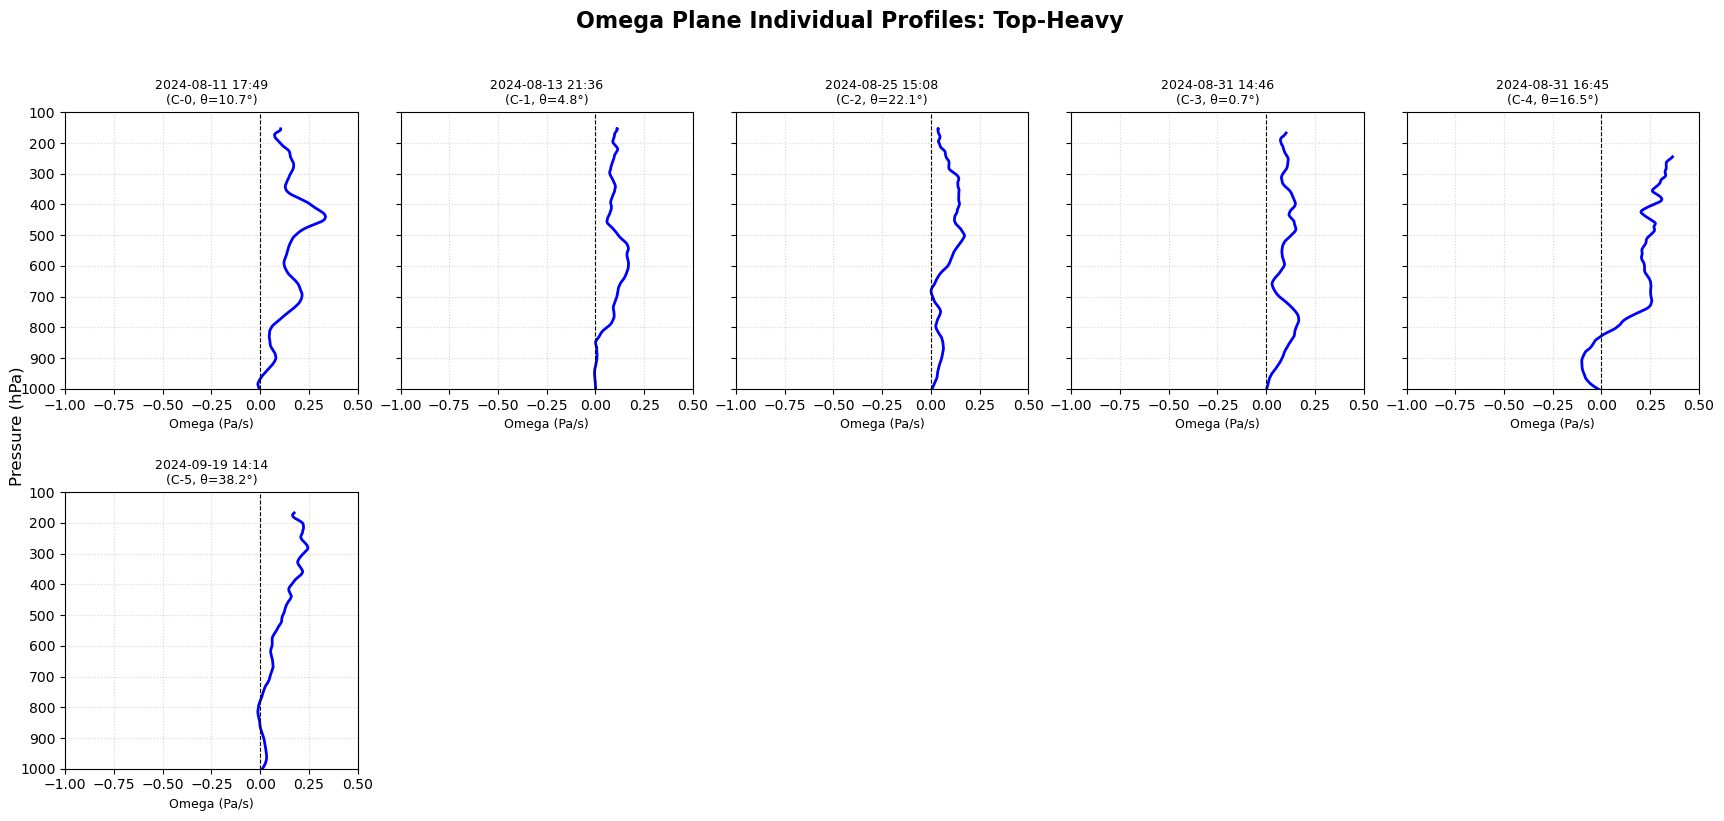


GENERATING AND SAVING PLOTS FOR: BOTTOM-HEAVY COMBINED
Total Circles: 6

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Method_Spaghetti_Bottom-Heavy_Combined.png


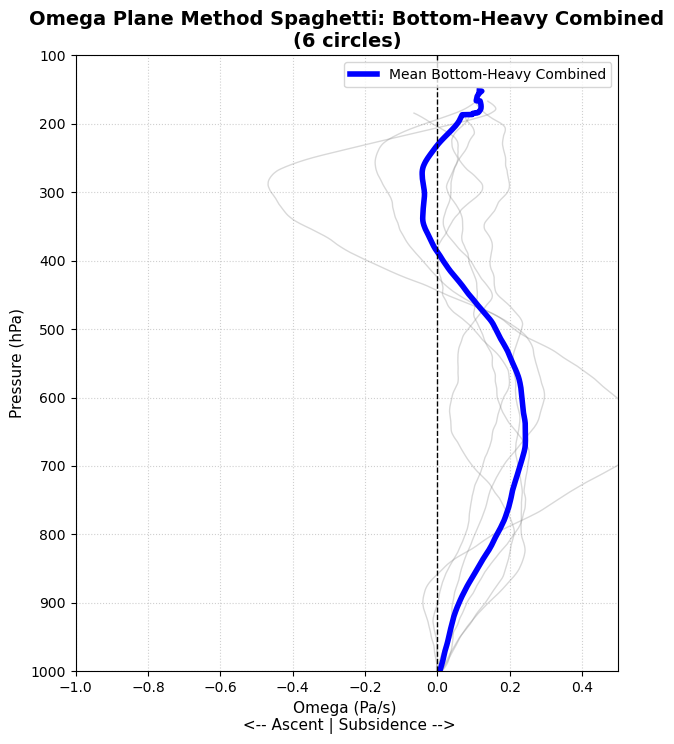

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Grid_Bottom-Heavy_Combined.png


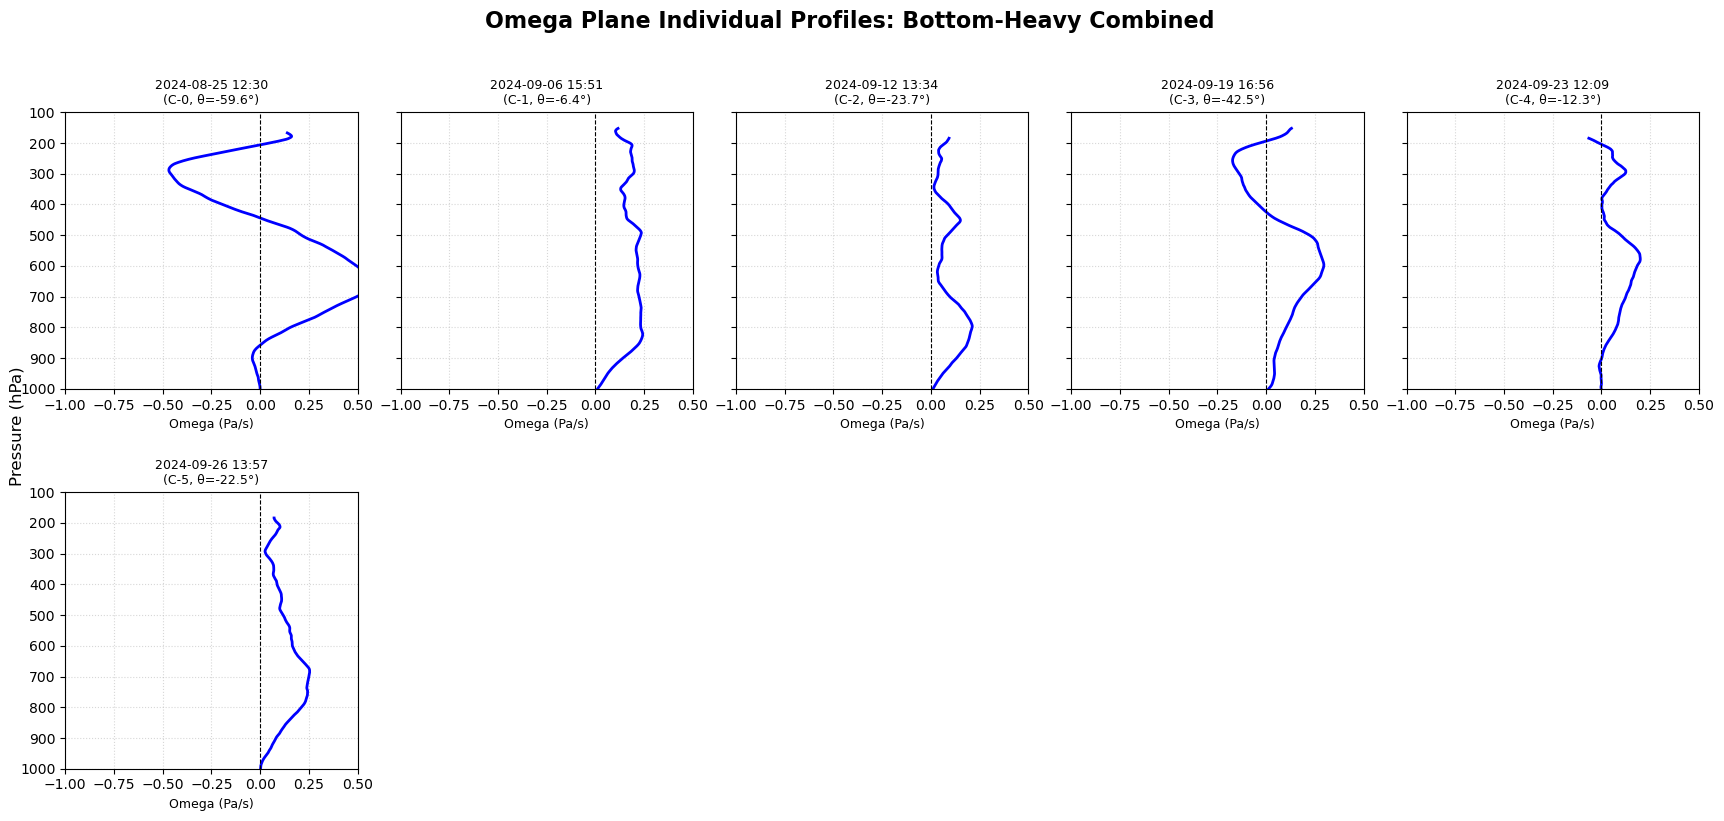


GENERATING AND SAVING PLOTS FOR: TOP-HEAVY COMBINED
Total Circles: 6

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Method_Spaghetti_Top-Heavy_Combined.png


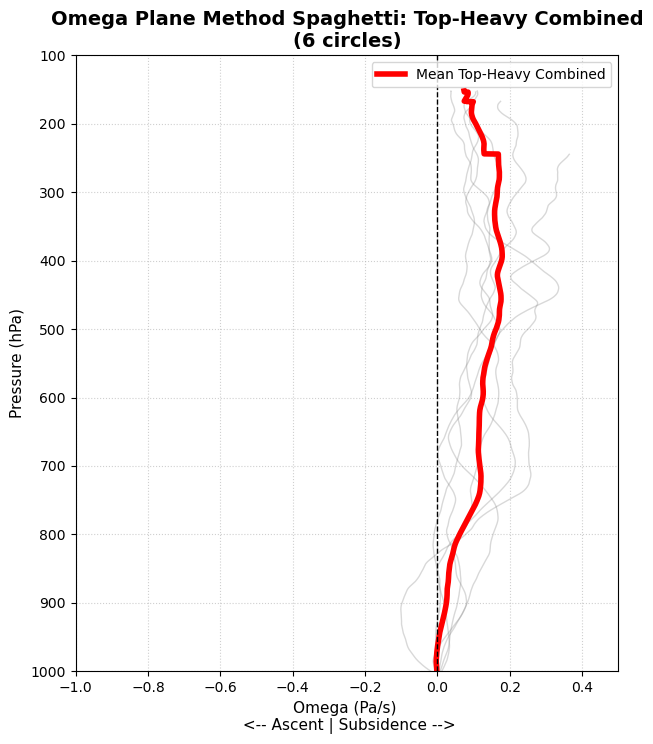

Saved: /home/565/zr7147/Proj/Plot-Figs/Omega Plane_Grid_Top-Heavy_Combined.png


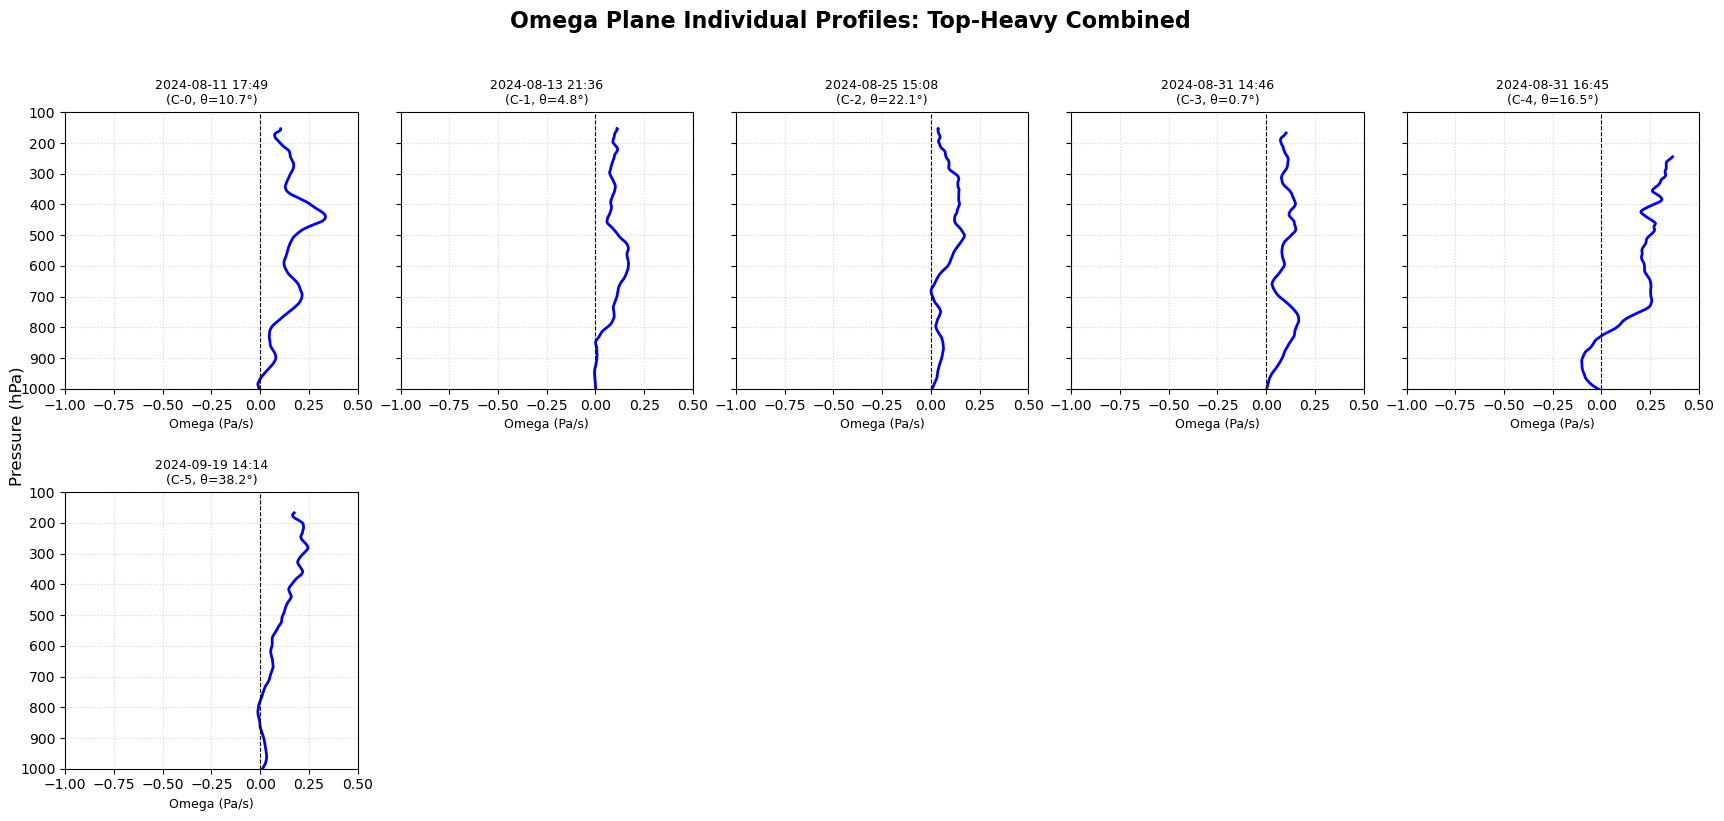

In [6]:

# 1. Define your exact Gadi output directory
output_dir = "/home/565/zr7147/Proj/Plot-Figs"
os.makedirs(output_dir, exist_ok=True) 

# ---------------------------------------------------------
# 2. SELECT CATEGORIZATION MODE (TOGGLE HERE)
# ---------------------------------------------------------

# Option a: Omega Plane (Singh & Li 2025 - Angle Method)
mode_prefix = "Omega Plane"
category_var = "category_plane"

# Option b: Simple Average Method (Upper vs Lower Troposphere)
# mode_prefix = "AvgMethod"
# category_var = "category_avg"


# Get a list of unique categories using your selected toggle, skipping "Missing Data"
valid_categories = [cat for cat in np.unique(ds[category_var].values) if cat != "Missing Data"]

# Define consistent axes limits for fair comparison
x_limits = (-1.0, 0.5)
y_limits = (1000, 100) # Pressure in hPa.

# ---------------------------------------------------------
# Helper: generate spaghetti + individual grid plots
# ---------------------------------------------------------
def plot_category_group(ds_cat, circle_indices, group_label, safe_label, color_mean='red'):
    n_circles = len(circle_indices)

    print(f"\n{'='*60}")
    print(f"GENERATING AND SAVING PLOTS FOR: {group_label.upper()}")
    print(f"Total Circles: {n_circles}")
    print(f"{'='*60}\n")

    # ---------------------------------------------------------
    # PLOT TYPE 1: THE "SPAGHETTI" PLOT
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(7, 8))

    for c in circle_indices:
        profile = ds_cat['omega'].sel(circle=c)
        pressure = ds_cat['p_mean'].sel(circle=c) / 100
        ax1.plot(profile, pressure, color='gray', alpha=0.3, linewidth=1)

    mean_profile = ds_cat['omega'].mean(dim='circle')
    mean_pressure = ds_cat['p_mean'].mean(dim='circle') / 100

    ax1.plot(mean_profile, mean_pressure, color=color_mean, linewidth=4, label=f'Mean {group_label}')

    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_xlim(x_limits)
    ax1.set_ylim(y_limits)

    ax1.set_xlabel('Omega (Pa/s) \n <-- Ascent | Subsidence -->', fontsize=11)
    ax1.set_ylabel('Pressure (hPa)', fontsize=11)
    ax1.set_title(f'Omega Plane Method Spaghetti: {group_label}\n({n_circles} circles)', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    fig1_path = os.path.join(output_dir, f'{mode_prefix}_Method_Spaghetti_{safe_label}.png')
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {fig1_path}")
    plt.show()

    # ---------------------------------------------------------
    # PLOT TYPE 2: THE INDIVIDUAL GRID PLOTS
    # ---------------------------------------------------------
    cols = 5
    rows = math.ceil(n_circles / cols)

    if n_circles > 0:
        fig2, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*4), sharex=True, sharey=True)
        if n_circles == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, c in enumerate(circle_indices):
            profile = ds_cat['omega'].sel(circle=c)
            pressure = ds_cat['p_mean'].sel(circle=c) / 100

            raw_time = ds_cat['circle_time'].sel(circle=c).values
            datetime_str = pd.Timestamp(raw_time).strftime('%Y-%m-%d %H:%M')

            angle_val = float(ds_cat['top_heaviness_angle'].sel(circle=c).values)
            angle_str = f"{angle_val:.1f}°" if not np.isnan(angle_val) else "N/A"

            axes[i].plot(profile, pressure, color='blue', linewidth=2)
            axes[i].axvline(0, color='black', linestyle='--', linewidth=0.8)

            axes[i].set_title(f'{datetime_str}\n(C-{c}, θ={angle_str})', fontsize=9)
            axes[i].grid(True, linestyle=':', alpha=0.5)
            axes[i].tick_params(labelbottom=True)
            axes[i].set_xlabel('Omega (Pa/s)', fontsize=9)

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        axes[0].set_xlim(x_limits)
        axes[0].set_ylim(y_limits)

        fig2.suptitle(f'{mode_prefix} Individual Profiles: {group_label}', fontsize=16, fontweight='bold', y=1.02)
        fig2.supylabel('Pressure (hPa)', fontsize=12)

        plt.tight_layout(h_pad=2.0)

        fig2_path = os.path.join(output_dir, f'{mode_prefix}_Grid_{safe_label}.png')
        fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {fig2_path}")
        plt.show()


# ---------------------------------------------------------
# 3. INDIVIDUAL CATEGORY PLOTS
# ---------------------------------------------------------
for cat in valid_categories:
    safe_cat_name = str(cat).replace(" / ", "_").replace(" ", "_").replace("(", "").replace(")", "")
    cat_mask = ds[category_var] == cat
    ds_cat = ds.isel(circle=cat_mask)
    circle_indices = ds_cat.circle.values
    plot_category_group(ds_cat, circle_indices, group_label=cat, safe_label=safe_cat_name)


# ---------------------------------------------------------
# 4. COMBINED CATEGORY PLOTS
# ---------------------------------------------------------
combined_groups = {
    "Bottom-Heavy Combined": {
        "categories": ["Bottom-Heavy", "Bottom-Heavy (Fully Ascending)"],
        "safe_label": "Bottom-Heavy_Combined",
        "color_mean": "blue",
    },
    "Top-Heavy Combined": {
        "categories": ["Top-Heavy", "Top-Heavy (Fully Ascending)"],
        "safe_label": "Top-Heavy_Combined",
        "color_mean": "red",
    },
}

for group_label, cfg in combined_groups.items():
    combined_mask = np.isin(ds[category_var].values, cfg["categories"])
    ds_combined = ds.isel(circle=combined_mask)
    circle_indices = ds_combined.circle.values
    if len(circle_indices) == 0:
        print(f"No circles found for {group_label}, skipping.")
        continue
    plot_category_group(ds_combined, circle_indices,
                        group_label=group_label,
                        safe_label=cfg["safe_label"],
                        color_mean=cfg["color_mean"])
